In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('HR_comma_sep.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
#DATA QUALITY CHECK

# Clean column names
df.columns = df.columns.str.lower().str.strip()

print("INFO:\n")
print(df.info())

print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# Drop duplicates
df = df.drop_duplicates()

INFO:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
None

Missing Values:
 satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
work_accident            0
left         

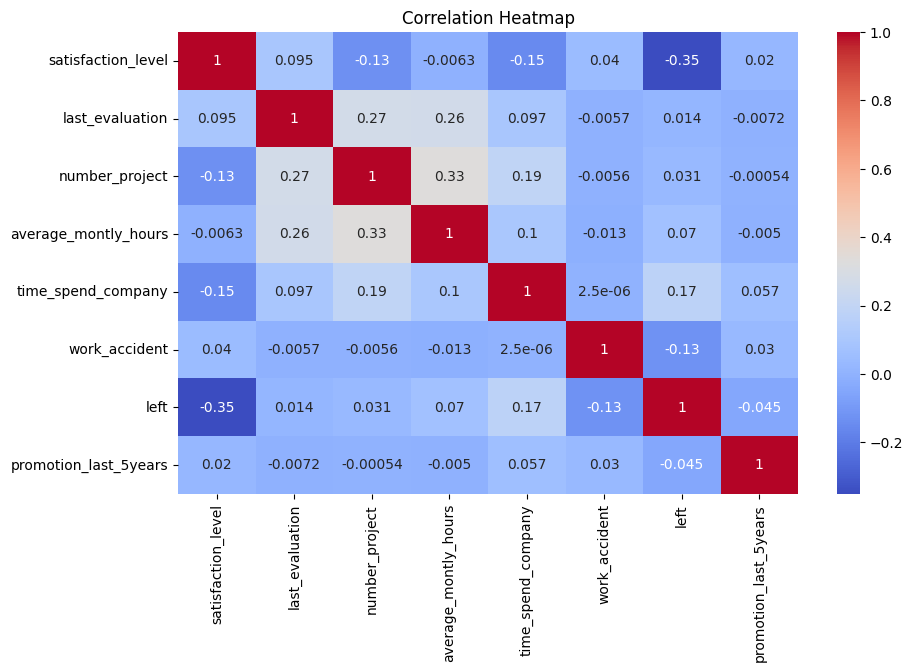

In [ ]:
#EDA (Exploratory Data Analysis)

#Correlation Heatmap
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

- Satisfaction level has a strong negative correlation with employee turnover.
- Employees with lower satisfaction are more likely to leave the company.
- Time spent in the company shows a positive relationship with turnover, indicating possible burnout.

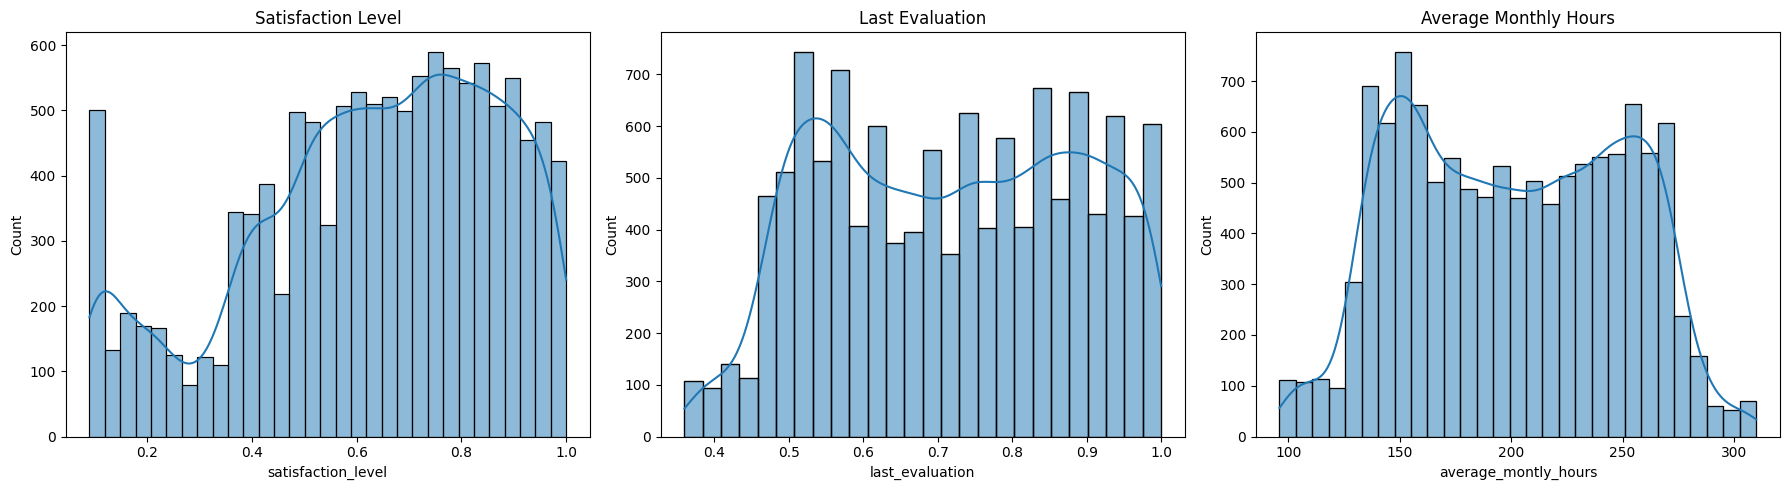

In [ ]:
#Distribution Plots
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1 row, 3 columns

sns.histplot(df['satisfaction_level'], kde=True, ax=axes[0])
axes[0].set_title("Satisfaction Level")

sns.histplot(df['last_evaluation'], kde=True, ax=axes[1])
axes[1].set_title("Last Evaluation")

sns.histplot(df['average_montly_hours'], kde=True, ax=axes[2])
axes[2].set_title("Average Monthly Hours")

plt.tight_layout()
plt.show()

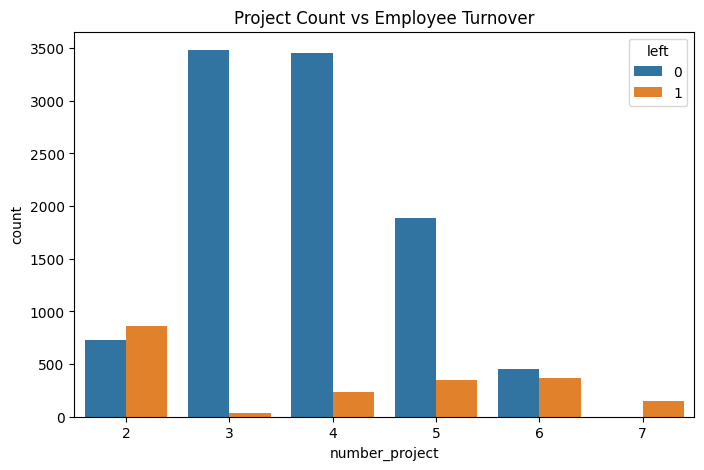

In [ ]:
#Project Count vs Turnover
plt.figure(figsize=(8,5))
sns.countplot(x='number_project', hue='left', data=df)
plt.title("Project Count vs Employee Turnover")
plt.show()

- Employees with very low number of projects are disengaged and tend to leave.
- Employees with very high number of projects are overworked and also tend to leave.
- This shows a U-shaped relationship between workload and turnover.

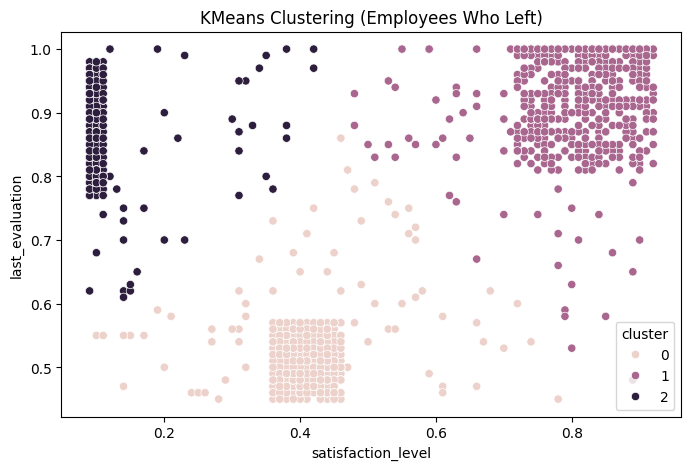

In [ ]:
#CLUSTERING (ONLY EMPLOYEES WHO LEFT)

df_left = df[df['left'] == 1].copy()

X_cluster = df_left[['satisfaction_level', 'last_evaluation']]

kmeans = KMeans(n_clusters=3, random_state=42)
df_left['cluster'] = kmeans.fit_predict(X_cluster)

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='satisfaction_level',
    y='last_evaluation',
    hue='cluster',
    data=df_left
)
plt.title("KMeans Clustering (Employees Who Left)")
plt.show()

- Cluster 1: Low satisfaction and low evaluation → disengaged employees.
- Cluster 2: Low satisfaction and high evaluation → overworked high performers.
- Cluster 3: High satisfaction and high evaluation → unexpected exits.

Cluster 2 is the most critical group for HR intervention.

In [ ]:
#PREPROCESSING


#Encode categorical columns
df = pd.get_dummies(df, columns=['sales', 'salary'], drop_first=True)

#Split features & target
X = df.drop('left', axis=1)
y = df['left']

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=123
)

In [ ]:
#SMOTE (ONLY TRAIN DATA)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [ ]:
#MODEL EVALUATION FUNCTION

def evaluate_model(model, X, y, name):
    print(f"\n===== {name} =====")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    y_pred = cross_val_predict(model, X, y, cv=skf)
    y_prob = cross_val_predict(model, X, y, cv=skf, method='predict_proba')[:,1]

    print("\nClassification Report:\n", classification_report(y, y_pred))

    cm = confusion_matrix(y, y_pred)
    print("Confusion Matrix:\n", cm)

    roc = roc_auc_score(y, y_prob)
    print("ROC-AUC:", roc)

    fpr, tpr, _ = roc_curve(y, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc:.2f})")

- Recall is more important than precision in this problem.
- Missing an employee who is likely to leave (false negative) is costly.
- Gradient Boosting performed best due to higher recall and ROC-AUC.


===== Logistic Regression =====

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.77      0.79      9142
           1       0.78      0.82      0.80      9142

    accuracy                           0.79     18284
   macro avg       0.80      0.79      0.79     18284
weighted avg       0.80      0.79      0.79     18284

Confusion Matrix:
 [[7053 2089]
 [1660 7482]]
ROC-AUC: 0.8629477538595811

===== Random Forest =====

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      9142
           1       0.99      0.98      0.98      9142

    accuracy                           0.99     18284
   macro avg       0.99      0.99      0.99     18284
weighted avg       0.99      0.99      0.99     18284

Confusion Matrix:
 [[9097   45]
 [ 228 8914]]
ROC-AUC: 0.9975798841401717

===== Gradient Boosting =====

Classification Report:
               precision    recal

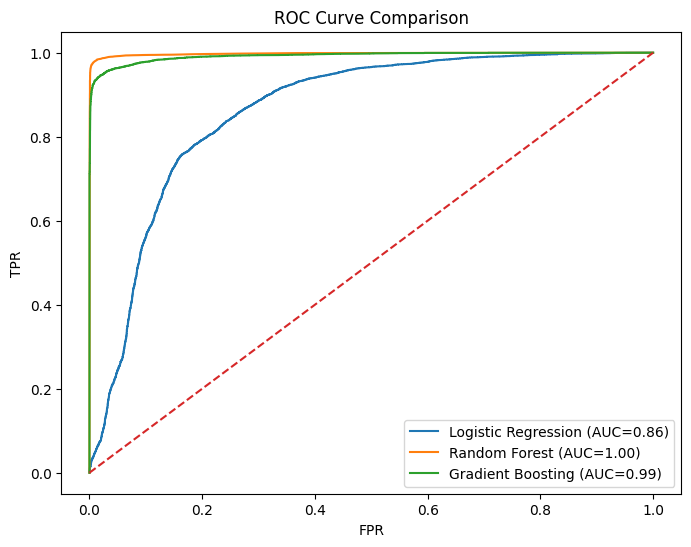

In [ ]:
#TRAIN MODELS

plt.figure(figsize=(8,6))

lr = LogisticRegression(max_iter=1000)
evaluate_model(lr, X_train_sm, y_train_sm, "Logistic Regression")

rf = RandomForestClassifier()
evaluate_model(rf, X_train_sm, y_train_sm, "Random Forest")

gb = GradientBoostingClassifier()
evaluate_model(gb, X_train_sm, y_train_sm, "Gradient Boosting")

plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()



In [ ]:
#FINAL MODEL


gb.fit(X_train_sm, y_train_sm)

y_test_pred = gb.predict(X_test)
y_test_prob = gb.predict_proba(X_test)[:,1]

print("Test Classification Report:\n", classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_prob))

Test Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      2286
           1       0.92      0.94      0.93       714

    accuracy                           0.97      3000
   macro avg       0.95      0.96      0.95      3000
weighted avg       0.97      0.97      0.97      3000

Confusion Matrix:
 [[2231   55]
 [  45  669]]
Test ROC-AUC: 0.9855296886908744


- Employee turnover is mainly influenced by satisfaction, workload, and growth opportunities.
- Machine learning models can effectively predict employee attrition.
- Early prediction helps HR take preventive actions and reduce turnover.

In [75]:
#RISK SEGMENTATION

def risk_category(p):
    if p < 0.2:
        return "Safe"
    elif p < 0.6:
        return "Low Risk"
    elif p < 0.9:
        return "Medium Risk"
    else:
        return "High Risk"

risk = [risk_category(p) for p in y_test_prob]

result = X_test.copy()
result['Actual'] = y_test.values
result['Turnover_Prob'] = y_test_prob
result['Risk'] = risk

result.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,...,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium,Actual,Turnover_Prob,Risk
10627,0.98,0.77,3,191,2,0,0,False,False,False,...,False,False,True,False,False,False,True,0,0.006753,Safe
2703,0.76,0.93,3,271,5,0,0,False,False,True,...,False,False,False,False,False,True,False,0,0.952433,High Risk
6059,0.70,0.93,3,185,4,0,0,False,True,False,...,False,False,False,False,False,False,True,0,0.079818,Safe
3258,0.48,0.61,3,223,3,1,0,False,False,False,...,False,False,False,True,False,False,True,0,0.013674,Safe
4565,0.57,0.90,3,144,2,0,0,False,False,False,...,False,False,False,False,False,False,True,0,0.025909,Safe
